In [1]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import pandas as pd

import re

In [2]:
#load in just the Arabidopsis Data set
df3 = pd.read_csv("/home/wenyuantong/Desktop/data/arabi_cross/100_150.csv", index_col=0)
df3.head()

,F4IB81_middle_191_325,Q0WP38_N-terminal_1_127,Q7XA66_C-terminal_93_242,Q8LAF9_N-terminal_1_113,Q940Y9_N-terminal_1_126,Q9C5H4_middle_131_261,Q9LNP6_C-terminal_213_328,Q9LUZ5_N-terminal_1_100,Q9LUZ5_middle_517_622,Q9SCU5_C-terminal_406_549,...,Q9C9J1_N-terminal_1_100,Q9CAV6_middle_290_393,Q9FMK8_IDP_1_138,Q9M0V4_N-terminal_1_131,Q9M158_N-terminal_1_104,F4I4Q1_C-terminal_188_303,Q6NN00_IDP_1_116,Q8VY68_IDP_1_113,Q9SZD3_IDP_1_115,Q9XFB0_N-terminal_1_115
F4IB81_middle_191_325,2.173744,4.955565,2.731385,1.004872,1.413445,2.018600,0.547160,2.448571,1.671656,0.792111,...,2.247709,-1.459587,2.059876,4.283379,2.857878,6.205853,3.050188,1.032668,1.311511,1.793946
Q0WP38_N-terminal_1_127,5.267727,15.548567,2.460256,0.243044,0.598914,3.479011,1.330661,6.113140,-5.940918,5.057411,...,1.999173,3.590195,0.562825,12.914173,4.733822,18.148154,8.185653,-0.061797,3.231808,1.948292
Q7XA66_C-terminal_93_242,2.458247,2.083016,4.102955,2.436277,3.095957,2.333399,1.293153,1.826779,5.169203,0.368553,...,3.267093,-2.266097,3.505828,1.571661,2.880411,2.355006,2.408988,2.570691,1.762559,3.112770
Q8LAF9_N-terminal_1_113,1.200511,0.273156,3.233996,1.537261,2.463209,0.900981,0.404432,0.918357,5.972982,-0.803547,...,2.594724,-3.640606,3.084627,0.200220,1.841420,0.710283,0.784952,1.659385,-0.169089,2.587987
Q940Y9_N-terminal_1_126,1.514405,0.603668,3.685663,2.209068,2.495591,1.997687,0.774155,1.172006,5.608511,-0.442412,...,2.929752,-3.110195,3.314959,0.858460,2.453430,1.005241,1.343525,2.286190,1.284145,2.456314


In [3]:
from sklearn.cluster import SpectralClustering

In [4]:
clustering = SpectralClustering(n_clusters=2,
        assign_labels='discretize',
        random_state=0).fit(df3)

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


KeyboardInterrupt: 

In [6]:
from umap import UMAP

In [7]:
# Select only numerical features for embedding
features = df3.select_dtypes(include=['number'])

# 2. Initialize and fit UMAP
reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(features)

# 3. Add results back to DataFrame for visualization
df3['umap_1'] = embedding[:, 0]
df3['umap_2'] = embedding[:, 1]

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
import plotly.express as px
fig = px.scatter(df, x='umap_1', y='umap_2', color='category_column')
fig.show()

ModuleNotFoundError: No module named 'plotly'

<Axes: xlabel='umap_1', ylabel='umap_2'>

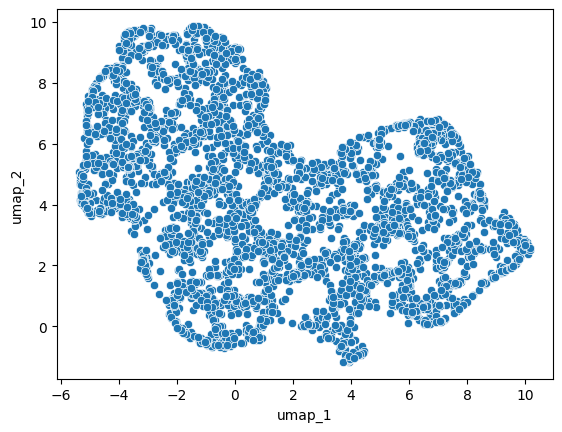

In [11]:
import seaborn as sns
sns.scatterplot(data=df3, x='umap_1', y='umap_2')


In [12]:
df3.plot(kind='line')

<Axes: >

Error in callback <function flush_figures at 0x71374e226ca0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
from pandas.plotting import scatter_matrix
scatter_matrix(df3, alpha=0.5, figsize=(6, 6), diagonal='kde')